# An Introduction to Nonparametric Statistics
### STAT 7110 — Quality Control
**Dr. Austin R. Brown**  
*Kennesaw State University*

---

### Table of Contents
1. [Introduction](#introduction)
2. [Statistical Power & Why Assumptions Matter](#statistical-power--why-assumptions-matter)
3. [Simulating Power Under Normality](#simulating-power-under-normality)
4. [Simulating Power Under Non-Normality](#simulating-power-under-non-normality)
5. [The Sign Test](#the-sign-test)
6. [Worked Example: The Sign Test](#worked-example-the-sign-test)
7. [The Wilcoxon Signed-Rank Test](#the-wilcoxon-signed-rank-test)
8. [Worked Example: The Wilcoxon Signed-Rank Test](#worked-example-the-wilcoxon-signed-rank-test)
9. [The Extended Median Test](#the-extended-median-test)
10. [Worked Example: The Extended Median Test](#worked-example-the-extended-median-test)
11. [The Kruskal-Wallis Test](#the-kruskal-wallis-test)
12. [Worked Example: The Kruskal-Wallis Test](#worked-example-the-kruskal-wallis-test)
13. [Where This Leaves Us](#where-this-leaves-us)


In [ ]:
## Clone your forked repository to Colab ##

## Specify your user name (change to your own):

#user_name <- "abrown9008"

## Set web address to forked repository (change to your own):

#repo_address <- paste0("www.github.com/", user_name, "/STAT-7110-Quality-Control")

## Check to see if repo is already cloned to Colab, and if not, clone repo:

#if(!dir.exists("STAT-7110-Quality-Control")) {
#  system(paste0("git clone ", repo_address))
#} else {
#  print("Repository already cloned to Colab.")
#}

## Set working drive to today's lecture (update the folder name to match your repo):

setwd("Slides//Week-11-Intro-to-NP-Statistics")

## Introduction

Suppose we hypothesize that the mean weight of high school football players in Georgia is greater than 163 pounds. To test this, we collect a random sample of players and calculate their sample mean weight and sample standard deviation. From an intro stats course, the obvious tool is a one-population $t$-test.

But there's a catch that intro courses often gloss over: the $t$-test assumes the data is normally distributed, or that the sample size is large enough for the Central Limit Theorem to kick in and bail us out. What happens if **neither** of those holds? Can we just run the test anyway and move on?

Let's see why that's a genuinely bad idea.

## Statistical Power & Why Assumptions Matter

Recall from earlier in the semester that the main way we compare competing control charts is via ARL. ARL, as we saw, is a function of statistical **power**. In words, power is the probability that a hypothesis test (and remember, a control chart is really just a hypothesis test applied repeatedly) correctly rejects the null hypothesis for a specific alternative that's actually true.

For a test statistic $T$ and significance level $\alpha$:

$$ \text{Power} = P(T > t_{\alpha} \,|\, H_1 \text{ is true}) $$

where $t_\alpha$ is the critical value for that significance level. If violating a test's assumptions quietly erodes its power, that's not just a theoretical concern. It's the same kind of problem that shows up as a degraded $ARL_1$ on a control chart that's silently the wrong tool for the data. Let's actually measure how much power we stand to lose.

## Simulating Power Under Normality

Let's run a small simulation to estimate the power of a one-population $t$-test, both when the normality assumption holds and when it doesn't. Using the football example:

$$ H_0: \mu \leq 163 \quad \text{vs.} \quad H_1: \mu > 163 $$

We could calculate this power directly, but simulation makes the intuition much more concrete. Suppose the *true* mean is 170 with a standard deviation of 10.

In [2]:
## Introduction to Nonparametric Statistics ##

library(tidyverse)

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   4.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the ]8;;http://conflicted.r-lib.org/conflicted package]8;; to force all conflicts to become errors


Warning message:
package ‘tidyverse’ was built under R version 4.5.3 


In [3]:
## Let's run a simulation to estimate power for a one-population
## t-test under various conditions ##

## Using the football example, suppose 
## H0: mu <= 163
## H1: mu > 163 ##

## We can calculate this power directly, but let's simulate it instead ##

## Suppose the true mean is 170, and the standard deviation is 10 ##

## Let's first set a seed for reproducability ##

set.seed(12345)

## Now, let's save a vector of results ##

b <- 10000

results <- vector('double',b)

## Now, let's run the simulation ##

for(i in 1:b){
  
  ## Generate a sample of size 5 from a normal distribution with mean 170 and sd 10 ##
  
  x <- rnorm(5,mean=170,sd=10)
  
  ## Run a one-sample t-test ##
  
  t <- t.test(x,mu=163,alternative='greater')
  
  ## Save the p-value ##
  
  results[i] <- t$p.value
  
}

In [4]:
## Now, let's calculate the power ##

length(which(results < 0.05))/b

[1] 0.3714

Given this true mean and a sample of only 5, we'd reject the (false) null roughly 37% of the time — not great. Let's see if a bigger sample fixes it.

In [5]:
## Let's try a larger sample size ##

results <- vector('double',b)

for(i in 1:b){
  
  ## Generate a sample of size 50 from a normal distribution with mean 170 and sd 10 ##
  
  x <- rnorm(50,mean=170,sd=10)
  
  ## Run a one-sample t-test ##
  
  t <- t.test(x,mu=163,alternative='greater')
  
  ## Save the p-value ##
  
  results[i] <- t$p.value
  
}

In [6]:
## Now, let's calculate the power ##

length(which(results < 0.05))/b

[1] 0.9991

Much better — over 99% power at $n=50$. Under normality, the $t$-test behaves exactly as advertised: more data buys more power, in a predictable way.

## Simulating Power Under Non-Normality

Now let's break the normality assumption on purpose. Suppose the data actually came from an **exponential** distribution instead:

$$ f(x) = \lambda e^{-\lambda x}, \quad x \geq 0,\quad E[X] = \frac{1}{\lambda},\quad Var[X] = \frac{1}{\lambda^2} $$

If the true mean is still 170, that means $\lambda = 1/170$.

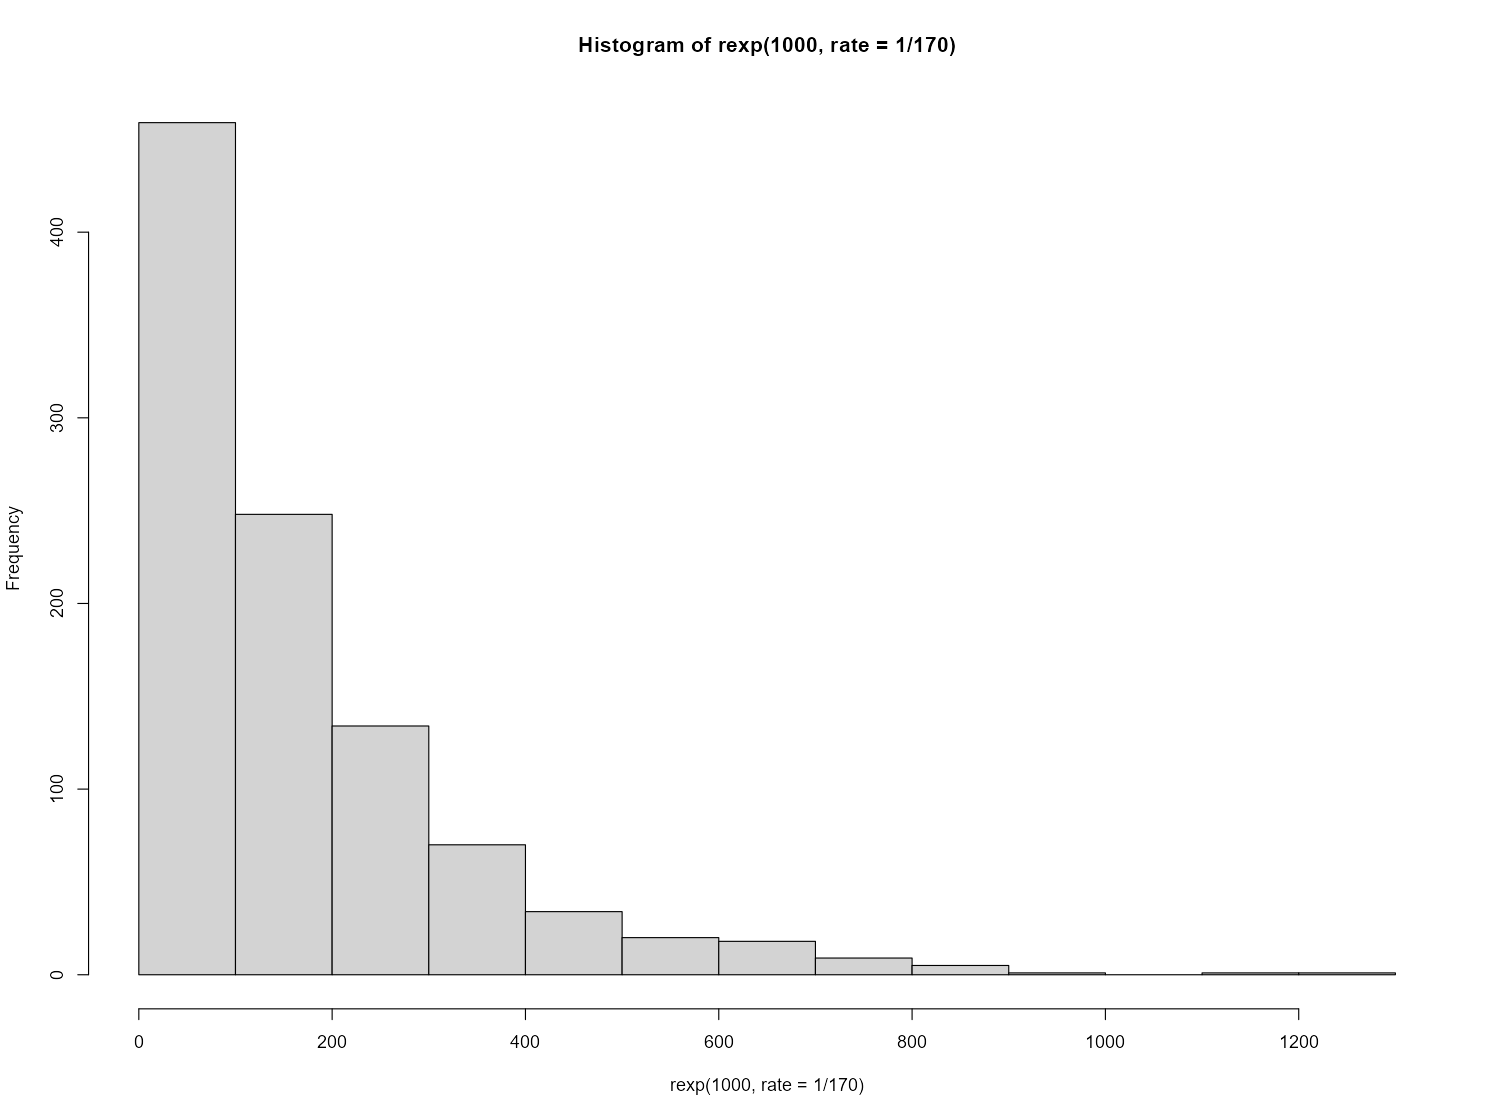

In [7]:
## Now what if our data did not come from a normal distribution 
## but instead came from the exponential distribution? ##

## Example of Exponential ##

## PDF of exponential is:
## f(x) = lambda * exp(-lambda*x) for x >= 0 ##
## where E[X] = 1/lambda and Var[X] = 1/lambda^2 ##

## So if the true mean is 170, this means lambda = 1/170 ##

hist(rexp(1000,rate=1/170))

Decidedly non-normal — strongly right-skewed, exactly the shape the $t$-test doesn't expect.

In [8]:
## Let's run the simulation again ##

results <- vector('double',b)

for(i in 1:b){
  
  ## Generate a sample of size 5 from an exponential distribution with rate 1/170 ##
  
  x <- rexp(5,rate=1/170)
  
  ## Run a one-sample t-test ##
  
  t <- t.test(x,mu=163,alternative='greater')
  
  ## Save the p-value ##
  
  results[i] <- t$p.value
  
}

In [9]:
## Now, let's calculate the power ##

length(which(results < 0.05))/b

[1] 0.0135

We went from 37% down to about 1% power. This is exactly why checking assumptions matters. But surely a bigger sample fixes this too, right? Let's check.

In [10]:
## Now, let's try a larger sample size ##

results <- vector('double',b)

for(i in 1:b){
  
  ## Generate a sample of size 50 from an exponential distribution with rate 1/170 ##
  
  x <- rexp(1000,rate=1/170)
  
  ## Run a one-sample t-test ##
  
  t <- t.test(x,mu=163,alternative='greater')
  
  ## Save the p-value ##
  
  results[i] <- t$p.value
  
}

In [11]:
## Now, let's calculate the power ##

length(which(results < 0.05))/b

[1] 0.3509

Still a severe loss of power, even at a much larger sample size. So we've got a real problem: if the data aren't (or can't reasonably be assumed to be) normal, how do we run hypothesis tests at all? **Nonparametric statistics** is exactly the toolkit built for this situation.

## The Sign Test

One alternative to the one-population $t$-test is the **Sign Test**. The key difference from most nonparametric methods: rather than testing the *mean*, we test the **median**.

$$ H_0: \tilde{\mu}_0 = C \quad \text{vs.} \quad H_1: \tilde{\mu}_0 \neq C $$

For a random sample of size $n$, the Sign Test statistic is:

$$ T = \sum_{i=1}^{n} I(X_i > C) $$

where:

$$ I(X_i > C) = \begin{cases} 1 & \text{if } X_i > C \\ 0 & \text{if } X_i \leq C \end{cases} $$

If $H_0$ is true and $\tilde{\mu} = C$, we'd expect $T$ to land around $n/2$ — roughly half the observations above $C$, half below. That means, under $H_0$:

$$ T \sim \text{Binomial}(n, 0.5) $$

and the p-value is calculated as:

$$ P = P(|T \geq t_\alpha| \,|\, H_0 \text{ is true}) $$

## Worked Example: The Sign Test

Let's use the `palmerpenguins` dataset. We'll take a random sample of 7 penguins and test:

$$ H_0: \text{median} = 3500 \quad \text{vs.} \quad H_1: \text{median} \neq 3500 $$

(body mass, in grams).

In [14]:
## Sign Test Example ##

## Using the penguins data, let's take a random sample of 
## size 7. ##

set.seed(7)

#install.packages('palmerpenguins')

data('penguins',package='palmerpenguins')

sample_penguins <- penguins |>
  na.omit() |>
  sample_n(7)

In [15]:
## Let's say I want to test:
## H_0: median = 3500 ##
## H_1: median != 3500 ##

## The test statistic is given by the number of observations
## greater than 3500 ##

T_Stat <- length(which(sample_penguins$body_mass_g > 3500))

## If we are using alpha = 0.05 and since this is a two-tailed 
## test, the p-value is given by ##

if(T_Stat > 7*0.5){
  
  p_value <- 2 * pbinom(T_Stat,size=7,prob=0.5,lower.tail=F)

  } else {
  
    p_value <- 2 * pbinom(T_Stat,size=7,prob=0.5,lower.tail=T)

}

print(p_value)

[1] 0.125


Since $0.125 > \alpha$, the data more substantially supports the null hypothesis. Now let's estimate the Sign Test's power under the same exponential, non-normal conditions that crushed the $t$-test earlier.

In [16]:
## Now let's run a simulation to estimate the power of the Sign Test 
## using the same conditions as the t-test before: ##

## Note:
## H0: median = 163 ##
## H1: median > 163 ##

## First, to make things easier, let's write a sign test 
## function ##

sign_test <- function(x,C){
  
  T_Stat <- length(which(x > C))
  
  if(T_Stat > length(x)*0.5){
  
    p_value <- 2 * pbinom(T_Stat,size=length(x),prob=0.5,lower.tail=F)
  
    } else {
  
    p_value <- 2 * pbinom(T_Stat,size=length(x),prob=0.5,lower.tail=T)
  
  }
  
  return(p_value)
  
}

np_results <- vector('double',b)

for(i in 1:b){
  
  ## Generate a sample of size 50 from an exponential distribution with rate 1/170 ##
  
  x <- rexp(50,rate=1/170)
  
  ## Run the Sign Test ##
  
  np_results[i] <- sign_test(x,log(2)/163)
  
}

In [17]:
## Now, let's calculate the power ##

length(which(np_results < 0.05))/b

[1] 1

We went from roughly 5% power (the $t$-test under non-normality) all the way up to essentially 100%. That's the entire case for nonparametric methods in one comparison: same non-normal data, wildly different power, just by testing the right thing (the median) in the right way.

## The Wilcoxon Signed-Rank Test

The Sign Test is a good alternative to the one-population $t$-test, but it's not the only one. One of its main limitations is that it throws away some information (it only cares whether each observation is above or below $C$, not by how much). A more famous and widely-used alternative is the **Wilcoxon Signed-Rank Test (WSRT)**, which also tests the median.

To calculate the WSRT statistic:

1. Rank the **absolute values** of the differences between each sample value and the hypothesized median.
2. Identify which of those differences were positive.
3. Sum the ranks belonging to the positive differences — that sum is the test statistic.

Unlike the Sign Test, the WSRT's null distribution is more complex: it's based on the total number of possible combinations of observed signed ranks, rather than a simple Binomial. As sample size grows, that exact distribution becomes computationally awkward, so in practice we typically fall back on a normal approximation instead — the same general strategy we've leaned on throughout the semester whenever an exact distribution gets unwieldy.

## Worked Example: The Wilcoxon Signed-Rank Test

Let's run the WSRT on the same penguin sample we used for the Sign Test, via R's built-in `wilcox.test()`.

In [18]:
## Wilcoxon Signed Rank Test ##

## Let's run the WSRT on the penguin data like
## we did before with the sign test! ##

wsrt <- wilcox.test(sample_penguins$body_mass_g,mu=3500,
                    alternative='two.sided')

print(wsrt$p.value)

[1] 0.078125


Same general conclusion as the Sign Test — but the WSRT typically has *more* power than the Sign Test in practice, precisely because it uses the magnitude of each deviation from $C$ (via the ranks), not just its direction.

## The Extended Median Test

The Sign Test and WSRT both handle a **single** sample against a hypothesized median. But what if we want to compare medians across **several independent groups** — the nonparametric analogue of a one-way ANOVA? That's exactly what the **Extended Median Test** (sometimes called Mood's Median Test) is built for.

Suppose we have $k$ independent samples and want to test:

$$ H_0: \tilde{\mu}_1 = \tilde{\mu}_2 = \dots = \tilde{\mu}_k \quad \text{vs.} \quad H_1: \text{at least one } \tilde{\mu}_j \text{ differs} $$

The idea is a natural extension of the Sign Test's logic:

1. Pool **all** observations across all $k$ groups and find the **grand median**, $\tilde{\mu}$.
2. For each group, count how many of its observations fall **above** the grand median, and how many fall **at or below** it.
3. Arrange those counts into a $2 \times k$ contingency table.
4. Under $H_0$ (all groups share the same underlying median), each group should have roughly the same *proportion* of observations above vs. below the grand median. That's a classic test of independence — so we run a $\chi^2$ test on the table.

$$ \chi^2 = \sum_{\text{all cells}}\frac{(O - E)^2}{E} \;\dot{\sim}\; \chi^2_{k-1} \text{ under } H_0$$

The big appeal: like the Sign Test, this only requires knowing whether each observation is above or below a reference point — it makes very few distributional assumptions, which makes it a genuinely robust choice when group distributions might be quite different shapes, not just shifted versions of each other.

## Worked Example: The Extended Median Test

Let's use the full `penguins` dataset (not just a sample of 7) to test whether body mass differs across the three species — Adelie, Chinstrap, and Gentoo:

$$ H_0: \tilde{\mu}_{Adelie} = \tilde{\mu}_{Chinstrap} = \tilde{\mu}_{Gentoo} \quad \text{vs.} \quad H_1: \text{at least one differs} $$

In [19]:
## Extended Median Test Example ##

penguins_clean <- penguins |>
  na.omit()

## Step 1: Find the grand median across all species ##

grand_median <- median(penguins_clean$body_mass_g)

grand_median

[1] 4050

In [20]:
## Step 2 & 3: Build a 2 x k table of counts above/at-or-below the grand median, by species ##

above_below <- ifelse(penguins_clean$body_mass_g > grand_median,
                       "Above","At or Below")

med_table <- table(above_below,penguins_clean$species)

med_table

             
above_below   Adelie Chinstrap Gentoo
  Above           32        11    118
  At or Below    114        57      1

In [21]:
## Step 4: Run a chi-square test of independence on the table ##

chisq.test(med_table)


	Pearson's Chi-squared test

data:  med_table
X-squared = 192.05, df = 2, p-value < 2.2e-16


With such a small p-value, we have strong evidence the species don't all share the same median body mass — which shouldn't be surprising if you know your penguins (Gentoos are considerably larger). 

## The Kruskal-Wallis Test

The Extended Median Test is a reasonable multi-group tool, but like the Sign Test, it only uses each observation's position *relative to a threshold* — above or below the grand median — discarding how far above or below it actually is. The **Kruskal-Wallis Test** fixes that the same way the WSRT improved on the Sign Test: by working with **ranks** instead of a simple above/below split. It's the nonparametric analogue of a one-way ANOVA (and closely related to running a Mann-Whitney/Wilcoxon rank-sum test across more than two groups at once).

For $k$ independent samples, pooled into a single set of $N$ observations:

1. Rank **all** $N$ observations together, ignoring group membership (ties get the average rank, just like the WSRT).
2. For each group $j$, sum its ranks: $R_j$.
3. Calculate the test statistic:

$$ H = \frac{12}{N(N+1)}\sum_{j=1}^{k}\frac{R_j^2}{n_j} - 3(N+1) $$

where $n_j$ is the sample size of group $j$. Under $H_0$ (all groups share the same underlying distribution), and for reasonably large $n_j$:

$$ H \;\dot\sim\; \chi^2_{k-1} $$

Because it uses the full rank information rather than collapsing each observation to a single above/below indicator, the Kruskal-Wallis test is typically **more powerful** than the Extended Median Test when the assumption of similarly-shaped group distributions is reasonable — the same tradeoff we saw between the WSRT and the Sign Test in the one-sample case.

## Worked Example: The Kruskal-Wallis Test

Let's rerun the same species comparison, this time with the Kruskal-Wallis test, using R's built-in `kruskal.test()`.

In [22]:
## Kruskal-Wallis Test Example ##

kruskal.test(body_mass_g ~ species, data = penguins_clean)


	Kruskal-Wallis rank sum test

data:  body_mass_g by species
Kruskal-Wallis chi-squared = 212.09, df = 2, p-value < 2.2e-16


Same conclusion as the Extended Median Test, strong evidence the species differ in body mass. We can see the difference in power through a comparison of the test statistics (192 vs 212).

## Where This Leaves Us

We now have a small nonparametric toolkit that mirrors familiar parametric tests:

| Parametric test | Nonparametric alternative(s) | What it tests |
|---|---|---|
| One-sample $t$-test | Sign Test, Wilcoxon Signed-Rank Test | One population median vs. a constant |
| One-way ANOVA | Extended Median Test, Kruskal-Wallis Test | Equality of medians across $k \geq 2$ independent groups |

In every case, the nonparametric version trades a normality assumption for a much weaker one (often just that observations are independent, and sometimes that groups share a similar distributional shape), at the cost of some power *when the parametric assumptions actually hold*. But as we saw at the start of this notebook, when those assumptions **don't** hold, that tradeoff runs the other way, sometimes dramatically.

So far, everything we've covered has been hypothesis testing in the general statistics sense, not control charting specifically. In the next notebook, we'll bring these same nonparametric ideas into an actual Phase II control charting framework, building a nonparametric CUSUM chart based on the Wilcoxon Signed-Rank statistic.